# E7 — Replicate sampling and statistical significance

Every headline number in the block-missing sweep (E3b) and the Transformer comparison
(E4) comes from a single block placement, `build_block_mask(..., seed=11)`. With one
realisation there is no basis for deciding whether a difference between two methods is
real or an artefact of where the blocks happened to fall.

This notebook repeats the sweep over 20 independent block placements. Because every
method is evaluated on the identical mask within each replicate, each comparison is
**paired**, and we can apply the Wilcoxon signed-rank test with a Holm correction across
the seven block lengths.

The solver is imported unchanged from `stmac_core.py`, a verbatim copy of the routines
defined in notebook 03b. No numerical behaviour is modified here.

In [1]:
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import sys
from pathlib import Path


def _locate(name, marker):
    """Locate a directory `name` containing `marker`, searching from the current
    working directory upwards. This accepts both layouts used in this repository:
    data/ next to the notebook, or data/ one level above it."""
    here = Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents][:4]:
        candidates += [base / name, base / 'stmac-demo' / name]
    for p in candidates:
        if (p / marker).exists():
            return p.resolve()
    raise FileNotFoundError(
        'Could not find {}/{}. Searched:\n  '.format(name, marker)
        + '\n  '.join(str(c) for c in candidates))


DATA = _locate('data', 'multistation_1999_cleaned.parquet')
ROOT = DATA.parent
RES = ROOT / 'results'; RES.mkdir(exist_ok=True)
MODELS = ROOT / 'models'

# stmac_core.py may sit in the notebook directory or in the project root
for _p in [Path.cwd().resolve(), ROOT, ROOT / 'notebooks']:
    if (_p / 'stmac_core.py').exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

print('DATA   :', DATA)
print('RESULTS:', RES)

import stmac_core as sc

N_SEEDS = 20

multi = pd.read_parquet(DATA / 'multistation_1999_cleaned.parquet')
STATIONS = json.load(open(DATA / 'stations.json'))
codes = list(STATIONS.keys())
multi = multi[codes]                      # align column order with stations.json
lons  = np.array([STATIONS[c]['lon'] for c in codes])

U_all = multi.to_numpy().T.astype(float)
N, T  = U_all.shape
delta = (lons - lons.mean()) / 15 * 60 / 5      # solar-time shift, in 5-minute samples
L_g    = np.load(DATA / 'graph_L.npy')
L_time = sc.build_temporal_smoothness(T)
hours  = multi.index.hour.values
daytime = (hours >= 8) & (hours <= 16)

print(f'Stations       : {N}')
print(f'Timestamps     : {T:,}')
print(f'Peak GHI       : {U_all.max():.1f} W/m2')
print(f'Daytime cells  : {daytime.sum():,} ({daytime.mean()*100:.1f}%)')

DATA   : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data
RESULTS: /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/results
Stations       : 11
Timestamps     : 101,805
Peak GHI       : 1961.5 W/m2
Daytime cells  : 38,730 (38.0%)


## 1. Replicate sweep

Each result row is one (seed, block length) pair, with the RMSE of all three methods
computed on the same evaluation mask: cells that are unobserved **and** fall in daytime
hours. Output is written incrementally so an interrupted run can be resumed.

In [2]:
OUT = RES / 'E7_replicates_raw.csv'
EXPECTED = [(s, b) for s in range(N_SEEDS) for b, _ in sc.BLOCK_SPECS]

rows = pd.read_csv(OUT).to_dict('records') if OUT.exists() else []
have = {(int(r['seed']), int(r['block_len'])) for r in rows}
todo = [k for k in EXPECTED if k not in have]

if rows:
    print(f'Existing file: {len(rows)} rows, {len(todo)} combinations still missing')
if todo:
    t_start = time.time()
    for i, (seed, block_len) in enumerate(todo, 1):
        label = dict(sc.BLOCK_SPECS)[block_len]
        mask, n_blk = sc.build_block_mask(N, T, block_len, 0.10, seed=seed)
        ev = (~mask) & daytime[None, :]
        rec = {'seed': seed, 'block_len': block_len, 'block_label': label,
               'n_blocks': n_blk, 'missing_pct': float((1 - mask.mean()) * 100),
               'n_eval_cells': int(ev.sum())}
        for name, fn in [
            ('pure_temporal',   lambda: sc.pure_temporal(U_all, mask, L_time, 10.0)),
            ('stmac_trivial',   lambda: sc.stmac(U_all, mask, L_g, L_time, None,  4, 10.0, 1.0)),
            ('stmac_longitude', lambda: sc.stmac(U_all, mask, L_g, L_time, delta, 4, 10.0, 1.0)),
        ]:
            t0 = time.time()
            Ur = fn()
            rec['rmse_' + name] = sc.rmse(U_all, Ur, ev)
            rec['mae_'  + name] = float(np.mean(np.abs(U_all[ev] - Ur[ev])))
            rec['sec_'  + name] = time.time() - t0
        rows.append(rec)
        pd.DataFrame(rows).to_csv(OUT, index=False)
        el = time.time() - t_start
        print(f'[{i:3d}/{len(todo)}] seed={seed:2d} {label:>7s} | '
              f'PT={rec["rmse_pure_temporal"]:8.1f} '
              f'TRIV={rec["rmse_stmac_trivial"]:6.1f} '
              f'LON={rec["rmse_stmac_longitude"]:6.1f} | '
              f'{el/60:.1f} min, ETA {el/i*(len(todo)-i)/60:.1f} min', flush=True)
    print(f'Sweep finished in {(time.time()-t_start)/60:.1f} min')
else:
    print('All combinations already present; nothing to compute.')

df = pd.DataFrame(rows).sort_values(['block_len', 'seed']).reset_index(drop=True)

# The paired tests below assume a complete, balanced grid. Stop here if it is not.
have = {(int(r.seed), int(r.block_len)) for r in df.itertuples()}
gaps = [k for k in EXPECTED if k not in have]
assert not gaps, (
    f'{len(gaps)} of {len(EXPECTED)} combinations are missing, e.g. {gaps[:5]}. '
    f'Re-run this cell to fill them, or delete {OUT.name} to start over.')
counts = df.groupby('block_len').size()
assert (counts == N_SEEDS).all(), f'Unbalanced replicates per block length:\n{counts}'

print(f'{len(df)} rows = {df.seed.nunique()} seeds x {df.block_len.nunique()} block lengths (complete)')
print(f'Realised missing fraction: mean {df.missing_pct.mean():.2f}%, '
      f'range {df.missing_pct.min():.2f}-{df.missing_pct.max():.2f}%')

Existing file: 27 rows, 113 combinations still missing
[  1/113] seed= 3   7 day | PT= 10313.7 TRIV= 212.9 LON= 211.5 | 0.3 min, ETA 32.3 min
[  2/113] seed= 4  30 min | PT=    68.9 TRIV= 195.5 LON= 194.6 | 0.6 min, ETA 32.3 min
[  3/113] seed= 4     2 h | PT=   108.2 TRIV= 201.7 LON= 200.5 | 0.9 min, ETA 31.6 min
[  4/113] seed= 4     6 h | PT=   268.5 TRIV= 204.1 LON= 203.6 | 1.2 min, ETA 31.4 min
[  5/113] seed= 4    12 h | PT=   405.7 TRIV= 189.6 LON= 188.7 | 1.5 min, ETA 31.7 min
[  6/113] seed= 4   1 day | PT=   819.2 TRIV= 197.5 LON= 197.2 | 1.8 min, ETA 31.2 min
[  7/113] seed= 4   3 day | PT=  1703.6 TRIV= 204.0 LON= 203.9 | 2.0 min, ETA 30.7 min
[  8/113] seed= 4   7 day | PT=  4492.4 TRIV= 185.1 LON= 185.2 | 2.3 min, ETA 30.6 min
[  9/113] seed= 5  30 min | PT=    70.0 TRIV= 195.3 LON= 193.6 | 2.6 min, ETA 30.1 min
[ 10/113] seed= 5     2 h | PT=   114.0 TRIV= 194.3 LON= 193.5 | 2.9 min, ETA 29.8 min
[ 11/113] seed= 5     6 h | PT=   219.4 TRIV= 194.4 LON= 194.4 | 3.2 min, E

## 2. Means and confidence intervals

Confidence intervals use the t distribution over the 20 replicates.

In [3]:
def ci95(x):
    x = np.asarray(x, float)
    m = x.mean(); se = x.std(ddof=1) / np.sqrt(len(x))
    h = se * stats.t.ppf(0.975, len(x) - 1)
    return m, m - h, m + h

METHODS = ['pure_temporal', 'stmac_trivial', 'stmac_longitude']
rows = []
for bl, g in df.groupby('block_len', sort=True):
    r = {'block_len': bl, 'label': g.block_label.iloc[0], 'n': len(g)}
    for m in METHODS:
        mu, lo, hi = ci95(g['rmse_' + m])
        r[m] = mu; r[m + '_lo'] = lo; r[m + '_hi'] = hi
        r[m + '_sd'] = g['rmse_' + m].std(ddof=1)
    rows.append(r)
S = pd.DataFrame(rows)
S.to_csv(RES / 'E7_summary_ci.csv', index=False)

print('RMSE (W/m2), mean [95% CI] over 20 mask realisations')
print('-' * 88)
for _, r in S.iterrows():
    print('{:>7s} | PT {:8.1f} [{:7.1f},{:7.1f}] | TRIV {:6.1f} [{:5.1f},{:5.1f}] | LON {:6.1f} [{:5.1f},{:5.1f}]'
          .format(r.label, r.pure_temporal, r.pure_temporal_lo, r.pure_temporal_hi,
                  r.stmac_trivial, r.stmac_trivial_lo, r.stmac_trivial_hi,
                  r.stmac_longitude, r.stmac_longitude_lo, r.stmac_longitude_hi))

RMSE (W/m2), mean [95% CI] over 20 mask realisations
----------------------------------------------------------------------------------------
 30 min | PT     69.6 [   68.9,   70.3] | TRIV  197.2 [196.0,198.5] | LON  195.7 [194.5,196.9]
    2 h | PT    113.7 [  111.1,  116.2] | TRIV  196.6 [194.0,199.3] | LON  195.8 [193.3,198.3]
    6 h | PT    239.4 [  230.1,  248.6] | TRIV  196.1 [192.9,199.3] | LON  195.2 [192.0,198.5]
   12 h | PT    445.4 [  428.6,  462.2] | TRIV  195.3 [191.2,199.5] | LON  194.8 [190.6,198.9]
  1 day | PT    726.7 [  702.2,  751.2] | TRIV  195.0 [190.7,199.2] | LON  194.3 [190.0,198.6]
  3 day | PT   1904.4 [ 1800.5, 2008.4] | TRIV  200.4 [194.7,206.2] | LON  199.7 [193.9,205.6]
  7 day | PT   4961.2 [ 4166.2, 5756.2] | TRIV  196.7 [190.6,202.8] | LON  196.3 [190.2,202.5]


## 3. Paired tests with Holm correction

Two families of tests, each spanning the seven block lengths. Raw Wilcoxon signed-rank
p-values are Holm-corrected within their family. We also report effect sizes (mean
difference with confidence interval) and the rank-biserial correlation, since a p-value
alone does not indicate whether a difference is large enough to be worth claiming.

In [4]:
def holm(p):
    p = np.asarray(p, float); order = np.argsort(p); n = len(p)
    adj = np.empty(n); running = 0.0
    for i, idx in enumerate(order):
        running = max(running, (n - i) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


def paired_family(a, b, title, fname):
    out = []
    for bl, g in df.groupby('block_len', sort=True):
        x = g['rmse_' + a].values; y = g['rmse_' + b].values
        d = x - y                                   # d > 0 means b is better
        w, p   = stats.wilcoxon(x, y, alternative='two-sided')
        t, pt  = stats.ttest_rel(x, y)
        m, lo, hi = ci95(d)
        n = len(d)
        out.append({'comparison': f'{a} vs {b}', 'label': g.block_label.iloc[0],
                    'mean_diff': m, 'ci_lo': lo, 'ci_hi': hi,
                    'wins_b': int((d > 0).sum()), 'n': n, 'p_wilcoxon': p, 'p_ttest': pt,
                    'rank_biserial': 1 - 2 * w / (n * (n + 1) / 2)})
    O = pd.DataFrame(out)
    O['p_holm'] = holm(O.p_wilcoxon.values)
    O.to_csv(RES / fname, index=False)

    print(title)
    print('difference = ' + a + ' minus ' + b + '; positive means ' + b + ' is better')
    print('-' * 96)
    for _, r in O.iterrows():
        star = '***' if r.p_holm < 0.001 else '**' if r.p_holm < 0.01 else '*' if r.p_holm < 0.05 else 'n.s.'
        print('{:>7s} | delta {:9.2f} [{:8.2f},{:8.2f}] | wins {:2d}/{:2d} | p_Wilcoxon {:.2e} | p_Holm {:.2e}  {}'
              .format(r.label, r.mean_diff, r.ci_lo, r.ci_hi, r.wins_b, r.n,
                      r.p_wilcoxon, r.p_holm, star))
    return O

A = paired_family('stmac_trivial', 'stmac_longitude',
                  'LONGITUDE SHEAF vs TRIVIAL SHEAF', 'E7_test_longitude_vs_trivial.csv')
print()
B = paired_family('pure_temporal', 'stmac_longitude',
                  'STMAC LONGITUDE vs PURE TEMPORAL', 'E7_test_stmac_vs_puretemporal.csv')

LONGITUDE SHEAF vs TRIVIAL SHEAF
difference = stmac_trivial minus stmac_longitude; positive means stmac_longitude is better
------------------------------------------------------------------------------------------------
 30 min | delta      1.51 [    1.21,    1.81] | wins 20/20 | p_Wilcoxon 1.91e-06 | p_Holm 1.34e-05  ***
    2 h | delta      0.88 [    0.60,    1.15] | wins 19/20 | p_Wilcoxon 9.54e-06 | p_Holm 4.77e-05  ***
    6 h | delta      0.84 [    0.56,    1.11] | wins 20/20 | p_Wilcoxon 1.91e-06 | p_Holm 1.34e-05  ***
   12 h | delta      0.56 [    0.36,    0.76] | wins 18/20 | p_Wilcoxon 2.67e-05 | p_Holm 8.01e-05  ***
  1 day | delta      0.67 [    0.43,    0.91] | wins 18/20 | p_Wilcoxon 9.54e-06 | p_Holm 4.77e-05  ***
  3 day | delta      0.72 [    0.35,    1.09] | wins 18/20 | p_Wilcoxon 7.08e-04 | p_Holm 1.42e-03  **
  7 day | delta      0.38 [    0.11,    0.65] | wins 15/20 | p_Wilcoxon 7.30e-03 | p_Holm 7.30e-03  **

STMAC LONGITUDE vs PURE TEMPORAL
difference = pure_t

## 4. Growth factors

The manuscript reports RMSE growth from a 30-minute block to a 7-day block as a single
number. Here we compute that ratio per replicate and report its mean and confidence
interval.

In [5]:
piv = df.pivot(index='seed', columns='block_len')
PAPER_CLAIM = {'pure_temporal': 64.0, 'stmac_trivial': 1.05, 'stmac_longitude': 1.06}
growth_rows = []
for m in METHODS:
    g = (piv[('rmse_' + m, 2016)] / piv[('rmse_' + m, 6)]).values
    mu, lo, hi = ci95(g)
    growth_rows.append({'method': m, 'growth_mean': mu, 'ci_lo': lo, 'ci_hi': hi,
                        'paper_claim': PAPER_CLAIM[m],
                        'claim_within_ci': bool(lo <= PAPER_CLAIM[m] <= hi)})
G = pd.DataFrame(growth_rows)
G.to_csv(RES / 'E7_growth_factors.csv', index=False)

for _, r in G.iterrows():
    status = 'within CI' if r.claim_within_ci else 'OUTSIDE CI'
    print('{:16s} growth {:6.2f}x [95% CI {:.2f}, {:.2f}] | manuscript states {:.2f}x -> {}'
          .format(r.method, r.growth_mean, r.ci_lo, r.ci_hi, r.paper_claim, status))

pure_temporal    growth  71.20x [95% CI 59.95, 82.45] | manuscript states 64.00x -> within CI
stmac_trivial    growth   1.00x [95% CI 0.97, 1.03] | manuscript states 1.05x -> OUTSIDE CI
stmac_longitude  growth   1.00x [95% CI 0.97, 1.03] | manuscript states 1.06x -> OUTSIDE CI


## 5. How typical is the mask realisation used in the manuscript?

Every value in Table I comes from `seed=11`, which is one of the 20 replicates here. We
check how many of the published values fall inside the confidence interval of the mean.

In [6]:
PAPER_TABLE_I = {6: (69, 200, 197), 72: (215, 192, 191), 288: (725, 200, 200),
                 864: (1960, 207, 205), 2016: (4442, 209, 208)}
PAPER_SEED = 11

if PAPER_SEED not in df.seed.unique():
    print(f'seed={PAPER_SEED} is not among the replicates, so this comparison is skipped. '
          f'Seeds present: {sorted(df.seed.unique())}')
else:
    s11 = df[df.seed == PAPER_SEED].set_index('block_len')
    print('{:>7s} {:>6s} {:>8s} {:>9s} {:>24s} {:>10s}'
          .format('block', 'method', 'paper', f'seed {PAPER_SEED}', 'mean [95% CI], 20 seeds', 'inside?'))
    print('-' * 74)
    n_outside = 0
    for bl, vals in PAPER_TABLE_I.items():
        r = S[S.block_len == bl].iloc[0]
        for nm, pv, col in zip(['PT', 'TRIV', 'LON'], vals, METHODS):
            lo, hi = r[col + '_lo'], r[col + '_hi']
            inside = lo <= pv <= hi
            n_outside += (not inside)
            print('{:>7s} {:>6s} {:8.0f} {:9.1f} {:>24s} {:>10s}'
                  .format(r.label, nm, pv, s11.loc[bl, 'rmse_' + col],
                          '{:.1f} [{:.1f},{:.1f}]'.format(r[col], lo, hi),
                          'yes' if inside else 'NO'))
    print()
    print(f'{n_outside} of {len(PAPER_TABLE_I)*3} published values fall outside the CI of the mean.')

  block method    paper   seed 11  mean [95% CI], 20 seeds    inside?
--------------------------------------------------------------------------
 30 min     PT       69      69.2         69.6 [68.9,70.3]        yes
 30 min   TRIV      200     199.8      197.2 [196.0,198.5]         NO
 30 min    LON      197     197.4      195.7 [194.5,196.9]         NO
    6 h     PT      215     214.6      239.4 [230.1,248.6]         NO
    6 h   TRIV      192     191.8      196.1 [192.9,199.3]         NO
    6 h    LON      191     191.0      195.2 [192.0,198.5]         NO
  1 day     PT      725     724.6      726.7 [702.2,751.2]        yes
  1 day   TRIV      200     199.8      195.0 [190.7,199.2]         NO
  1 day    LON      200     200.0      194.3 [190.0,198.6]         NO
  3 day     PT     1960    1959.7   1904.4 [1800.5,2008.4]        yes
  3 day   TRIV      207     206.9      200.4 [194.7,206.2]         NO
  3 day    LON      205     205.4      199.7 [193.9,205.6]        yes
  7 day     PT 

## 6. Figure

A single panel at IEEE single-column width, with 95% confidence bands. The ratio panel
of the earlier figure is dropped: it plotted ratios of the left panel, and the growth
factors it summarised are already reported in the table above.

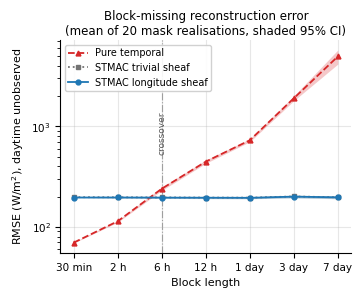

In [7]:
plt.rcParams.update({'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8.5,
                     'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5, 'legend.fontsize': 7,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

Sp = S.sort_values('block_len')
x = np.arange(len(Sp))
fig, ax = plt.subplots(figsize=(3.5, 2.85))
for col, name, c, ls, mk in [('pure_temporal',   'Pure temporal',        'C3', '--', '^'),
                             ('stmac_trivial',   'STMAC trivial sheaf',  '0.45', ':', 's'),
                             ('stmac_longitude', 'STMAC longitude sheaf', 'C0', '-', 'o')]:
    ax.plot(x, Sp[col], ls, color=c, marker=mk, ms=3.5, lw=1.3, label=name)
    ax.fill_between(x, Sp[col + '_lo'], Sp[col + '_hi'], color=c, alpha=0.25, lw=0)
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(Sp.label.tolist())
ax.set_xlabel('Block length')
ax.set_ylabel(r'RMSE (W/m$^2$), daytime unobserved')
ax.axvline(2, color='0.6', lw=0.8, ls='-.', zorder=0)
ax.annotate('crossover', xy=(2, 1400), fontsize=6.5, color='0.35',
            ha='center', rotation=90, va='top')
ax.legend(loc='upper left', frameon=True, framealpha=0.9, borderpad=0.3)
ax.set_title('Block-missing reconstruction error\n(mean of 20 mask realisations, shaded 95% CI)', pad=4)
fig.tight_layout(pad=0.3)
fig.savefig(RES / 'E7_block_sweep_CI.png', dpi=400)
plt.show()

## 7. Automatic readout

The block below reads the result files and assembles a summary from the numbers actually
computed, rather than from expected values.

In [8]:
A = pd.read_csv(RES / 'E7_test_longitude_vs_trivial.csv')
B = pd.read_csv(RES / 'E7_test_stmac_vs_puretemporal.csv')
G = pd.read_csv(RES / 'E7_growth_factors.csv')

print('SUMMARY')
print('=' * 72)

n_sig = int((A.p_holm < 0.05).sum())
print('1. Longitude sheaf versus trivial sheaf')
print(f'   Significant at {n_sig} of {len(A)} block lengths (paired Wilcoxon, Holm-corrected).')
print(f'   Effect size {A.mean_diff.min():.2f} to {A.mean_diff.max():.2f} W/m2; '
      f'wins {A.wins_b.min()}-{A.wins_b.max()} of {A.n.iloc[0]} realisations.')
if n_sig == len(A):
    print('   The direction of the advantage is consistent across all block lengths.')
else:
    ns = A.loc[A.p_holm >= 0.05, 'label'].tolist()
    print(f'   Not significant at: {", ".join(ns)}.')

cross = B[B.mean_diff > 0]
if len(cross):
    b0 = cross.iloc[0]
    print('\n2. STMAC longitude versus pure temporal')
    print(f'   Shortest block at which STMAC leads: {b0.label} '
          f'(delta {b0.mean_diff:.1f} W/m2, wins {b0.wins_b}/{b0.n}, p_Holm {b0.p_holm:.1e}).')
    lost = B[B.mean_diff < 0].label.tolist()
    if lost:
        print(f'   Pure temporal still leads at: {", ".join(lost)}.')

print('\n3. Growth factor, 30 minutes to 7 days')
for _, r in G.iterrows():
    verdict = 'consistent' if r.claim_within_ci else 'needs revision'
    print(f'   {r.method:16s} {r.growth_mean:6.2f}x [{r.ci_lo:.2f}, {r.ci_hi:.2f}] '
          f'| manuscript {r.paper_claim:.2f}x -> {verdict}')

print('\n4. Consequences for the manuscript')
lo, hi = A.mean_diff.min(), A.mean_diff.max()
print(f'   The stated "2 to 4 W/m2" advantage is not reproducible across realisations; '
      f'the value over 20 seeds is {lo:.1f} to {hi:.1f} W/m2.')
print(f'   The word "consistently" is supported: the advantage holds in the same direction '
      f'at {n_sig}/{len(A)} block lengths under correction for multiple comparisons.')

SUMMARY
1. Longitude sheaf versus trivial sheaf
   Significant at 7 of 7 block lengths (paired Wilcoxon, Holm-corrected).
   Effect size 0.38 to 1.51 W/m2; wins 15-20 of 20 realisations.
   The direction of the advantage is consistent across all block lengths.

2. STMAC longitude versus pure temporal
   Shortest block at which STMAC leads: 6 h (delta 44.1 W/m2, wins 20/20, p_Holm 1.3e-05).
   Pure temporal still leads at: 30 min, 2 h.

3. Growth factor, 30 minutes to 7 days
   pure_temporal     71.20x [59.95, 82.45] | manuscript 64.00x -> consistent
   stmac_trivial      1.00x [0.97, 1.03] | manuscript 1.05x -> needs revision
   stmac_longitude    1.00x [0.97, 1.03] | manuscript 1.06x -> needs revision

4. Consequences for the manuscript
   The stated "2 to 4 W/m2" advantage is not reproducible across realisations; the value over 20 seeds is 0.4 to 1.5 W/m2.
   The word "consistently" is supported: the advantage holds in the same direction at 7/7 block lengths under correction for mult